In [23]:
## 1. Data cleaning and preparation

#In this notebook, I clean and standardize the raw price data collected in Notebook 01. 
#The goal is to ensure:
#- Consistent time series across all assets
#- Minimal missing data issues
#- A clean dataset ready for factor construction and backtesting

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [25]:
## 2. Set project paths and load the data
project_root = Path.cwd().parent
raw_data_path = project_root / "data" / "raw"
price_data = pd.read_csv(raw_data_path / "prices.csv", index_col=0)
price_data.index = pd.to_datetime(price_data.index)
price_data.head()

,AAPL,ABBV,ACN,ADBE,AMZN,AVGO,BAC,BRK-B,COST,CRM,...,NFLX,NVDA,PEP,PG,SPY,TMO,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.304180,69.343697,136.707794,177.699997,59.450500,21.086664,24.637501,197.220001,168.498169,103.156616,...,20.107000,4.928266,91.602798,72.824974,236.562180,188.755341,193.090439,108.111893,28.855198,58.580410
2018-01-03,40.297169,70.428848,137.338745,181.039993,60.209999,21.317261,24.555098,199.789993,170.520294,104.026054,...,20.504999,5.252616,91.362259,72.736626,238.058426,192.217911,195.116013,109.188240,29.106905,59.730946
2018-01-04,40.484337,70.027191,138.964981,183.220001,60.479500,21.324373,24.876455,200.690002,169.196152,105.399376,...,20.563000,5.280303,91.812294,73.250755,239.061798,194.623978,195.962906,109.594223,29.133249,59.813625
2018-01-05,40.945267,71.246239,140.111267,185.339996,61.457001,21.450735,24.991816,201.419998,167.988174,106.802322,...,20.999001,5.325048,92.076111,73.298958,240.654968,197.959366,199.699677,112.218864,29.305927,59.765400
2018-01-08,40.793182,70.104713,141.231003,185.039993,62.343498,21.502064,24.818773,202.740005,168.641342,107.553200,...,21.205000,5.488212,91.548470,73.684570,241.095032,198.282166,196.233536,112.672043,29.739088,60.034088


In [26]:
## 3. Data validation
close_prices = price_data.copy()
print("Shape of the close price data:", close_prices.shape)
print("Start date:", close_prices.index.min())
print("End date:", close_prices.index.max())
print("Number of assest:", close_prices.shape[1])
print("Duplicate dates:", close_prices.index.duplicated().sum())
print("Duplicate tickers:", close_prices.columns.duplicated().sum())
print("Total missing values", close_prices.isna().sum().sum())

Shape of the close price data: (2076, 31)
Start date: 2018-01-02 00:00:00
End date: 2026-04-07 00:00:00
Number of assest: 31
Duplicate dates: 0
Duplicate tickers: 0
Total missing values 0


In [27]:
## 4. Check data type and sort
close_prices.info()
close_prices.sort_index()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2076 entries, 2018-01-02 to 2026-04-07
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2076 non-null   float64
 1   ABBV    2076 non-null   float64
 2   ACN     2076 non-null   float64
 3   ADBE    2076 non-null   float64
 4   AMZN    2076 non-null   float64
 5   AVGO    2076 non-null   float64
 6   BAC     2076 non-null   float64
 7   BRK-B   2076 non-null   float64
 8   COST    2076 non-null   float64
 9   CRM     2076 non-null   float64
 10  CVX     2076 non-null   float64
 11  GOOGL   2076 non-null   float64
 12  HD      2076 non-null   float64
 13  JPM     2076 non-null   float64
 14  KO      2076 non-null   float64
 15  LLY     2076 non-null   float64
 16  MA      2076 non-null   float64
 17  MCD     2076 non-null   float64
 18  META    2076 non-null   float64
 19  MRK     2076 non-null   float64
 20  MSFT    2076 non-null   float64
 21  NFLX    2076 non-nu

,AAPL,ABBV,ACN,ADBE,AMZN,AVGO,BAC,BRK-B,COST,CRM,...,NFLX,NVDA,PEP,PG,SPY,TMO,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.304180,69.343697,136.707794,177.699997,59.450500,21.086664,24.637501,197.220001,168.498169,103.156616,...,20.107000,4.928266,91.602798,72.824974,236.562180,188.755341,193.090439,108.111893,28.855198,58.580410
2018-01-03,40.297169,70.428848,137.338745,181.039993,60.209999,21.317261,24.555098,199.789993,170.520294,104.026054,...,20.504999,5.252616,91.362259,72.736626,238.058426,192.217911,195.116013,109.188240,29.106905,59.730946
2018-01-04,40.484337,70.027191,138.964981,183.220001,60.479500,21.324373,24.876455,200.690002,169.196152,105.399376,...,20.563000,5.280303,91.812294,73.250755,239.061798,194.623978,195.962906,109.594223,29.133249,59.813625
2018-01-05,40.945267,71.246239,140.111267,185.339996,61.457001,21.450735,24.991816,201.419998,167.988174,106.802322,...,20.999001,5.325048,92.076111,73.298958,240.654968,197.959366,199.699677,112.218864,29.305927,59.765400
2018-01-08,40.793182,70.104713,141.231003,185.039993,62.343498,21.502064,24.818773,202.740005,168.641342,107.553200,...,21.205000,5.488212,91.548470,73.684570,241.095032,198.282166,196.233536,112.672043,29.739088,60.034088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-31,253.789993,217.490005,198.289993,243.080002,208.270004,309.510010,48.750000,479.200012,996.429993,186.669998,...,96.150002,174.399994,155.289993,144.440002,650.340027,491.529999,270.589996,302.239990,124.279999,169.660004
2026-04-01,255.630005,214.979996,197.059998,241.369995,210.570007,313.489990,49.270000,478.500000,996.559998,186.240005,...,95.550003,175.750000,154.649994,144.089996,655.239990,494.540009,273.980011,298.510010,124.739998,160.779999
2026-04-02,255.919998,208.839996,201.330002,242.919998,209.770004,314.549988,49.380001,477.350006,1014.960022,187.179993,...,98.660004,177.389999,157.009995,143.119995,655.830017,491.459991,277.260010,300.799988,125.790001,160.690002


In [28]:
## 5. Check for non-positive values
non_positive_counts = (close_prices<=0).sum().sort_values(ascending=False)
problem_assets = non_positive_counts[non_positive_counts>0]
print(f"Number of non-positive values is: {len(problem_assets)}")
print(problem_assets)

Number of non-positive values is: 0
Series([], dtype: int64)


In [29]:
close_prices.describe()

,AAPL,ABBV,ACN,ADBE,AMZN,AVGO,BAC,BRK-B,COST,CRM,...,NFLX,NVDA,PEP,PG,SPY,TMO,UNH,V,WMT,XOM
count,2076.000000,2076.000000,2076.000000,2076.000000,2076.000000,2076.000000,2076.000000,2076.000000,2076.000000,2076.000000,...,2076.000000,2076.000000,2076.000000,2076.000000,2076.000000,2076.000000,2076.000000,2076.000000,2076.000000,2076.000000
mean,139.287949,119.199707,248.632182,402.792534,142.778965,90.745759,32.376875,311.792847,502.699339,206.346532,...,52.355689,48.773641,131.395377,123.652833,401.899861,443.961158,362.548703,219.979303,52.907532,75.837855
std,69.201811,50.904922,70.651165,121.075723,48.360874,94.771999,8.919168,106.573702,269.660798,56.232643,...,26.908990,58.455718,26.231888,29.993381,132.000192,132.696801,116.276442,66.204047,25.162205,30.233002
min,33.768074,48.014366,120.927467,177.699997,59.450500,14.411799,15.615929,162.130005,159.810181,102.781189,...,16.636999,3.150397,75.161980,57.956539,204.944885,188.755341,176.098145,107.498245,24.413351,23.985260
25%,66.672438,70.717129,178.895966,295.247498,95.049623,25.883880,25.158585,211.800003,274.413963,156.179874,...,33.315251,6.565419,111.066170,103.152828,275.840485,310.953773,249.606480,173.574963,36.253914,51.929696
50%,144.717659,120.028381,261.343613,385.205002,144.833496,48.159489,30.237657,288.370010,461.570007,204.870758,...,43.779501,18.582808,137.643135,129.049133,389.861893,491.196228,353.570526,208.851357,44.850634,68.224476
75%,188.219501,154.489475,303.901909,495.982491,176.470001,125.244205,38.336654,403.914993,715.525070,250.432327,...,62.147000,83.242512,153.816265,146.260643,493.111618,549.667618,471.305229,264.668938,58.238784,103.242472
max,285.922455,240.694290,394.312805,688.369995,254.000000,411.318512,56.928177,539.799988,1070.990479,365.067413,...,133.912994,207.017273,177.249710,173.840225,693.595764,659.204956,603.201172,371.152252,133.615784,171.470001


In [30]:
## 6. Summary stats
close_prices.describe().T.head()
daily_returns = close_prices.pct_change()
daily_returns.describe().T[["mean", "std", "min", "max"]].head()

,mean,std,min,max
AAPL,0.001072,0.019288,-0.128647,0.153288
ABBV,0.000669,0.016851,-0.162524,0.137673
ACN,0.000332,0.017625,-0.095881,0.128573
ADBE,0.000404,0.022661,-0.167932,0.177193
AMZN,0.000850,0.021612,-0.140494,0.135359


In [31]:
## 7. Check for extreme return
extreme_moves = (daily_returns.abs() > 0.2).sum().sort_values(ascending=False)
print(extreme_moves[extreme_moves > 0])

META    4
CVX     2
NFLX    2
UNH     1
AVGO    1
NVDA    1
CRM     1
dtype: int64


In [32]:
#Several assets (e.g., META, CVX, NFLX) exhibit daily returns exceeding 20%. 
#These extreme moves may correspond to earnings announcements, corporate actions such as stock splits, or potential data inconsistencies. 
#Further inspection of individual cases is required to distinguish between real market events and data anomalies.

In [33]:
## 8. Inspect META
meta_returns = daily_returns["META"]
meta_extreme = meta_returns[meta_returns.abs() > 0.2]
print(meta_extreme)

Date
2022-02-03   -0.263901
2022-10-27   -0.245571
2023-02-02    0.232824
2024-02-02    0.203176
Name: META, dtype: float64


In [34]:
close_prices.loc[meta_extreme.index, "META"]

Date
2022-02-03    235.908691
2022-10-27     97.177414
2023-02-02    187.300201
2024-02-02    471.291534
Name: META, dtype: float64

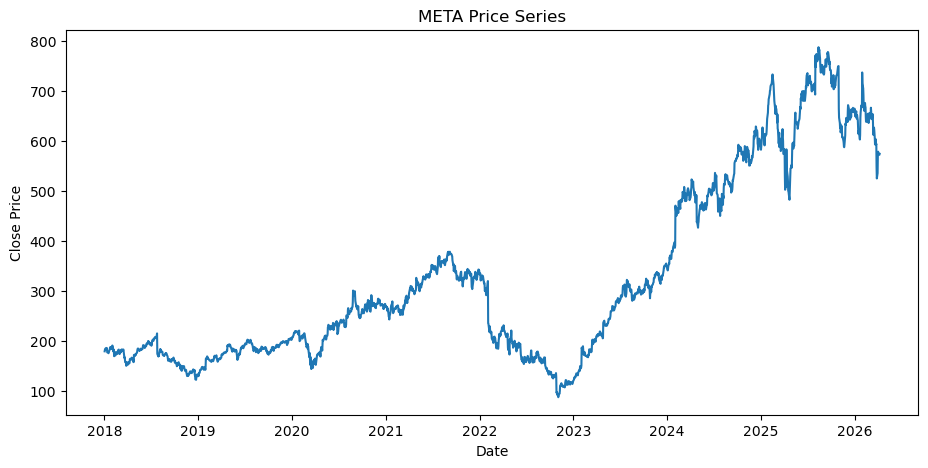

In [35]:
plt.figure(figsize=(11,5))
sns.lineplot(x=close_prices.index, y=close_prices["META"])
plt.title("META Price Series")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

In [36]:
#META exhibits several extreme daily returns (>20%), which upon inspection correspond to earnings announcements and major corporate developments. 
#These events represent genuine market reactions rather than data errors, so they are retained in the dataset.

In [37]:
## 9. Inspect NFLX
nflx_returns = daily_returns["NFLX"]
nflx_extreme = nflx_returns[nflx_returns.abs() > 0.2]
print(nflx_extreme)

Date
2022-01-21   -0.217905
2022-04-20   -0.351166
Name: NFLX, dtype: float64


In [38]:
close_prices.loc[nflx_extreme.index, "NFLX"]

Date
2022-01-21    39.750000
2022-04-20    22.618999
Name: NFLX, dtype: float64

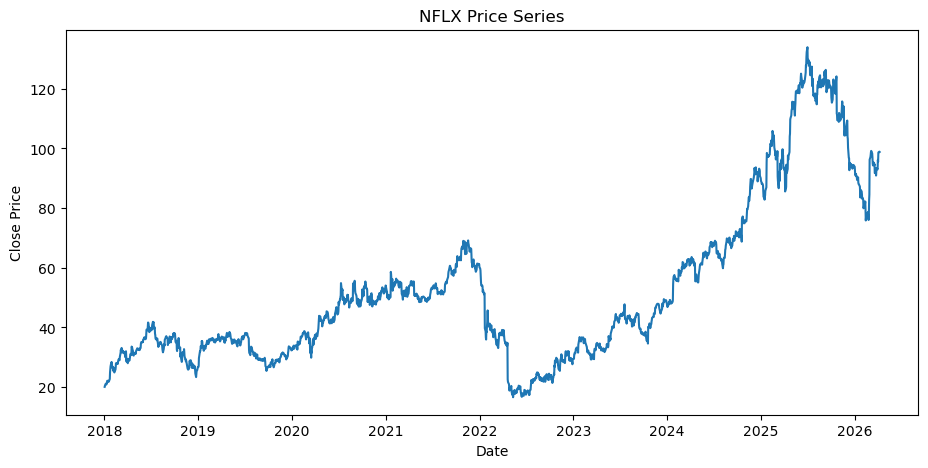

In [39]:
plt.figure(figsize=(11,5))
sns.lineplot(x=close_prices.index, y=close_prices["NFLX"])
plt.title("NFLX Price Series")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

In [40]:
## 10.Data Validation Conclusion:

#The dataset was validated for structural consistency, missing values, and financial plausibility. No non-positive prices or duplicate entries were detected.
#Extreme daily returns (>20%) were identified for several assets, including META and NFLX. Upon inspection, these events correspond to earnings announcements and major corporate developments rather than data errors.
#Therefore, the dataset is considered clean and suitable for downstream return modeling and portfolio analysis.

In [22]:
project_root = Path.cwd().parent
clean_path = project_root / "data" / "processed"
clean_path.mkdir(parents=True, exist_ok=True)
close_prices.to_csv(clean_path / "clean_close_prices.csv")
daily_returns.to_csv(clean_path / "daily_returns.csv")